# col_wise_concatination of ib77 and ib97_to_df_ib
1. df_mf_ib77_nn_s  & df_mf_ib97_nn_s  in via pickle
2. Concatenate df77 and df97 to df_mf_ib7797_nn
3. Remove duplicates cols
4. Remove duplicates rows
5. sort by timestamp
6. rename to df_ib
7. Save df_ib to pickle
8. ***Tested df_7797_n_s written to pickle as df_ib*** 

In [2]:
# Imports required for Loading, sorting .csx files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
#from sys_funcs import 

In [3]:
# set print rows  This worksheet sets maximum # of rows printed
pd.set_option('display.max_rows', 1000)  # Adjust the number of rows to display
# pd.reset_option('display.max_rows')  
print('print set to 1000 rows max' )

print set to 1000 rows max


## def functions

In [1]:
# def scale_mean_to_one(series):
def scale_mean_to_one(series):
    """Scale a Pandas Series so that its mean becomes 1."""
    mean_val = series.mean()
    return series / mean_val

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# def write_df_to_pickle(df, filename):
def write_df_to_pickle(df, filename):
    """
    Writes a DataFrame to a pickle file.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe to save.
    filename : str
        The pickle filename, e.g. 'mydata.pkl'.
    """
    df.to_pickle(filename)

# usage 
# write_df_to_pickle(df, "df.pkl")


### def functions plotters

#### plot_1col

#usage: plot_1col("df_mf_ib7797_nn_s_mrn", "ECW/TBW")
# def plot_column(df, col_name):
import matplotlib.pyplot as plt

def plot_1col(df, col_name):
    """
    Plot a single column from a dataframe.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing the column.
    col_name : str
        The name of the column to plot.
    """
    plt.figure(figsize=(10, 4))
    plt.plot(df[col_name], marker='o', linestyle='-', linewidth=1)
    plt.title(f"{col_name} over index")
    plt.xlabel("Index")
    plt.ylabel(col_name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [6]:
# plot_1col(df_mf_ib7797_nn_s_mrn, "ECW/TBW")

#### plot_2cols same axis [ ie col & filtered col]

**best plotter with assignable df and dual cols def**

In [7]:
# plot_2cols same axis [ ie col & filtered col]
def plot_2cols(plt_col_a, plt_col_b):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # Ensure timestamp is datetime
    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot first variable
    ax.plot(
        df["timestamp"],
        df[plt_col_a],
        marker="o",
        label=plt_col_a
    )

    # Plot second variable
    ax.plot(
        df["timestamp"],
        df[plt_col_b],
        marker="o",
        label=plt_col_b
    )

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title(f"{plt_col_a} & {plt_col_b} over time")
    plt.legend()
    plt.tight_layout()
    plt.show()


**best plotter with assignable df and dual cols caller**

#plt_lst = ['Weight',"ECW/TBW", 'BMR (Basal Metabolic Rate)',"SMM (Skeletal Muscle Mass)",'VFA (Visceral Fat Area)']
plot_multi_dual(df_mf_ib7797_nn_s_mrn, "ECW/TBW", "BMR (Basal Metabolic Rate)")
#plot_multi_dual(df_mf_ib7797_nn_s_mrn, "ECW/TBW")
#plot_multi_dual(df_mf_ib7797_nn_s_mrn, "ECW/TBW", "BMR (Basal Metabolic Rate)","VFA (Visceral Fat Area)")

#### plot_2cols_dual

In [8]:
# usage: plot_2cols_dua("ECW/TBW", "Weight", "BMI", "TBW")
# adds a second y‑axis for the second variable.
def plot_2cols_dual(plt_col_a, plt_col_b):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # Work on a safe copy
    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # First variable (left y-axis)
    ax1.plot(
        df["timestamp"],
        df[plt_col_a],
        marker="o",
        color="tab:blue",
        label=plt_col_a
    )
    ax1.set_ylabel(plt_col_a, color="tab:blue")

    # Second variable (right y-axis)
    ax2 = ax1.twinx()
    ax2.plot(
        df["timestamp"],
        df[plt_col_b],
        marker="o",
        color="tab:red",
        label=plt_col_b
    )
    ax2.set_ylabel(plt_col_b, color="tab:red")

    # Minor ticks every day
    ax1.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Grid on major ticks
    ax1.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(f"{plt_col_a} and {plt_col_b} over time")
    plt.tight_layout()
    plt.show()


plot_2cols_dual("ECW/TB Go moist this is W", "BMR (Basal Metabolic Rate)")

#### Plot_multi_cols_dual [Individual scalling -- all axis on tr side]

In [9]:
# usage: plot_multi_dual("ECW/TBW", "Weight", "BMI", "TBW")

def plot_multi_same_axis(*cols):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    df = df_mf_ib7797_nn_s_mrn.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig, ax = plt.subplots(figsize=(12, 5))

    for col in cols:
        ax.plot(df["timestamp"], df[col], marker="o", label=col)

    # Daily minor ticks
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Weekly major ticks
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Reading updated data from Pickle [77 97 & wrkng list]

### Reading updated data from Pickle [df_mf_ib77_nn_s]

In [10]:
# import df_mf_ib77_nn_s  from pickle
df_mf_ib77_nn_s = pd.read_pickle("df_mf_ib77_nn_s.pkl")
# verify df_mf_ib77_nn_s

### Reading updated data from Pickle [df_mf_ib97_nn_s]

In [11]:
# import df_mf_ib77_nn_s  from pickle
df_mf_ib97_nn_s = pd.read_pickle("df_mf_ib97_nn_s.pkl")
# verify df_mf_ib97_nn_s

## Concatenate the two dataframes on timestamp, keeping [["timestamp", "ib_id","ID"] + plt_lst]

### Select the [plt_lst]

# the list of columns you want to include in the analysis and plotting
plt_lst = ["ECW/TBW",
           "BMR (Basal Metabolic Rate)",
           "SMM (Skeletal Muscle Mass)",
           "VFA (Visceral Fat Area)"]
# verify plt_lst

### Read the file created in CoL_wise_import_77 [df_mf_ib77_nn_s] to df77

In [12]:
# read df_mf_ib77_nn_s to df77 
df_mf_ib97_nn_s = pd.read_pickle("df_mf_ib97_nn_s.pkl")
df97 = df_mf_ib97_nn_s
# verify df97

### Read the file created in CoL_wise_import_97 [df_mf_ib97_nn_s] to df97

In [13]:
# read df_mf_ib77_nn_s to df77 
df_mf_ib77_nn_s = pd.read_pickle("df_mf_ib77_nn_s.pkl")
df77 = df_mf_ib77_nn_s
# verify df77

In [14]:
print(" # verified df_mf_ib77_nn_s & # verify df_mf_ib97_nn_s has been LOADED")

 # verified df_mf_ib77_nn_s & # verify df_mf_ib97_nn_s has been LOADED


### Concatenate df77 and df97 to df_ib [formerly df_mf_ib7797_nn]

In [15]:
# calc
df_mf_ib7797_nn = pd.concat([df77, df97], ignore_index=True)
# verify df_mf_ib7797_nn

### Sort "df_mf_ib7797_nn" in order ascending timestamp to "df_mf_ib7797_nn_s"

In [16]:
# Sort works needs to reindex after sort
df_mf_ib7797_nn_s = df_mf_ib7797_nn.sort_values(by="timestamp", ascending=True)
# verify print (df_mf_ib7797_nn_s[["timestamp","ID"] + plt_lst]) 
# verify _ib7797_nn_s[["timestamp","ID","dtv"]]) 

### Rename "df_mf_ib7797_nn_s"  to "df_ib" and write to pickle

In [17]:
df_ib = df_mf_ib7797_nn_s
# verify df_ib

###  Write "df_ib" to pickle

In [18]:
# write to pickle
write_df_to_pickle(df_ib, "df_ib.pkl")
# verify 

# start Building series of plots ===================================================================================

In [19]:
# This allows the full 77 data frame with columns to sort out for 7797 morning evening ETC
df_ib = df_mf_ib77_nn_s
list(df_ib.columns)

#write_df_to_pickle(df_mf_ib77_nn_s, "df_mf_ib77_nn_s.pkl")
#print("df_mf_ib77_nn_s written to pickle")
# verify df_mf_ib77_nn_s

['timestamp',
 'dtv',
 'ib_id',
 'cls',
 'cmmnts',
 'Name',
 'ID',
 'Height',
 'Date of Birth',
 'Age',
 'Mobile Number',
 'Phone Number',
 'Zip Code',
 'Address',
 'E-mail',
 'Date of Registration',
 'Memo',
 'Test Date / Time',
 'Weight',
 'TBW (Total Body Water)',
 'ICW (Intracellular Water)',
 'ECW (Extracellular Water)',
 'DLM (Dry Lean Mass)',
 'BFM (Body Fat Mass)',
 'LBM (Lean Body Mass)',
 'SMM (Skeletal Muscle Mass)',
 'BMI (Body Mass Index)',
 'PBF (Percent Body Fat)',
 'LBM of Right Arm',
 'LBM% of Right Arm',
 'LBM of Left Arm',
 'LBM% of Left Arm',
 'LBM of Trunk',
 'LBM% of Trunk',
 'LBM of Right Leg',
 'LBM% of Right Leg',
 'LBM of Left Leg',
 'LBM% of Left Leg',
 'Leg Lean Mass',
 'TBW of Right Arm',
 'TBW of Left Arm',
 'TBW of Trunk',
 'TBW of Right Leg',
 'TBW of Left Leg',
 'ICW of Right Arm',
 'ICW of Left Arm',
 'ICW of Trunk',
 'ICW of Right Leg',
 'ICW of Left Leg',
 'ECW of Right Arm',
 'ECW of Left Arm',
 'ECW of Trunk',
 'ECW of Right Leg',
 'ECW of Left Leg

## Filter for "mrn" & "eve"

In [20]:
# mrn
df_mf_ib7797_nn_s_mrn = df_mf_ib7797_nn_s[df_mf_ib7797_nn_s["ib_id"] == "mrn"]
# verify df_mf_ib7797_nn_s_mrn

In [21]:
# eve
df_mf_ib7797_nn_s_eve = df_mf_ib7797_nn_s[df_mf_ib7797_nn_s["ib_id"] == "eve"]
# verify df_mf_ib7797_nn_s_eve 

## Normalize and Subract 1 on "df_mf_ib7797_nn_s[plt_lst]" col by col

In [22]:
# df_mf_ib7797_nn_s_mrn_n0 = df_mf_ib7797_nn_s_mrn.copy() 
df_mf_ib7797_nn_s_mrn_n0 = df_mf_ib7797_nn_s_mrn.copy() 
# VERIFY df_mf_ib7797_nn_s_mrn_n0

# Calculate normalized 0 mean lists
for plt_col in plt_lst:
    print(" \n Normalized and zero averaged \n", plt_col)
    df_mf_ib7797_nn_s_mrn_n0[plt_col]  =   scale_mean_to_one(df_mf_ib7797_nn_s_mrn[plt_col])-1
    print(df_mf_ib7797_nn_s_mrn_n0[plt_col])
    # plot_column(df_mf_ib7797_nn_s_mrn_n0, plt_col)

for plt_col in plt_lst:
    print("Now plotting:", plt_col)
    df_mf_ib7797_nn_s_mrn_n0[plt_col]  =   scale_mean_to_one(df_mf_ib7797_nn_s_mrn[plt_col])-1
    plot_column(df_mf_ib7797_nn_s_mrn_n0, plt_col)

# Creating a plot of value using **"df_mf_ib7797_nn_s_mrn"**

In [3]:
# verify 
df_mf_ib7797_nn_s_mrn

NameError: name 'df_mf_ib7797_nn_s_mrn' is not defined

In [24]:
def plot_multi_dual(df, *cols):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    
    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()
    plt.show()


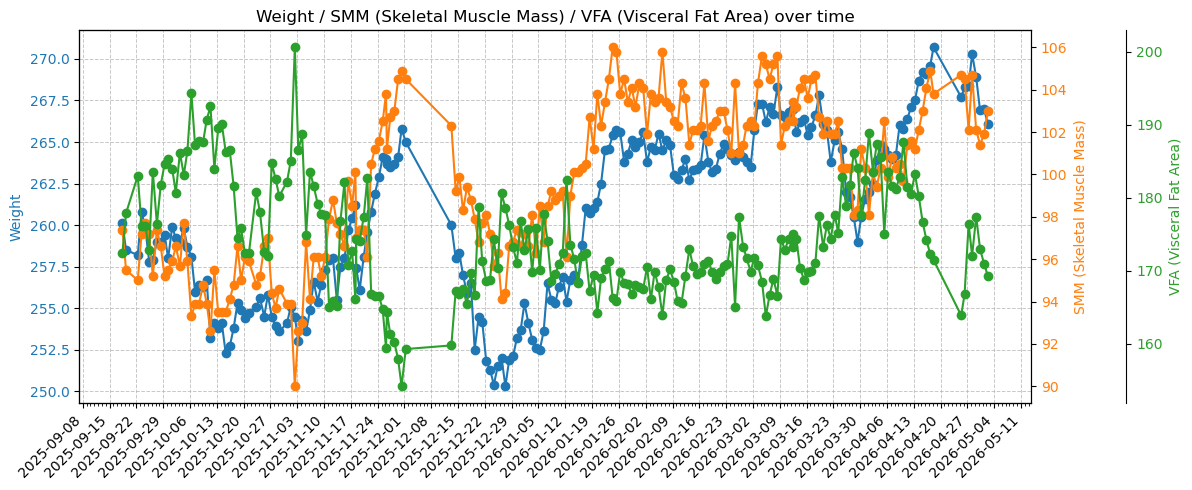

In [25]:
# Plots by subject weighth distribution
plt_lst = ['Weight',"SMM (Skeletal Muscle Mass)",'VFA (Visceral Fat Area)']
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst )

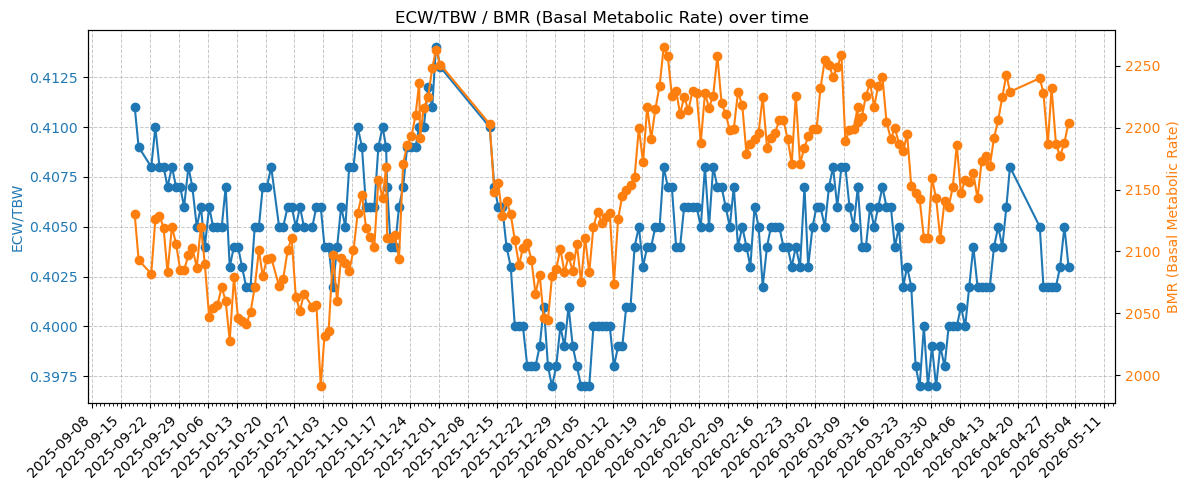

In [26]:
# Plots by subject inflamation and BMR
plt_lst = ["ECW/TBW", 'BMR (Basal Metabolic Rate)']
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst )

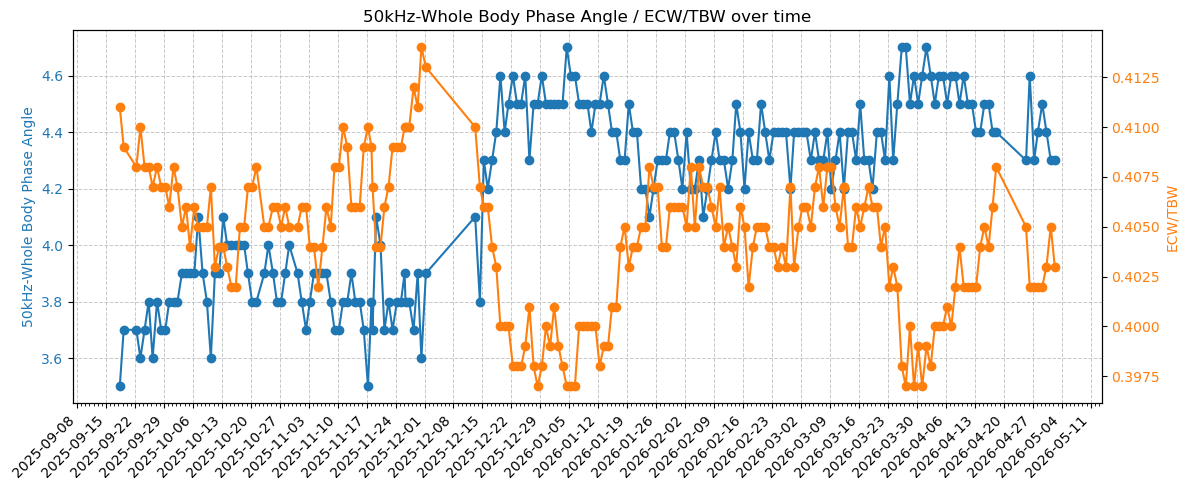

In [27]:
# Plots by subject
plt_lst = ['50kHz-Whole Body Phase Angle',"ECW/TBW"]
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst )

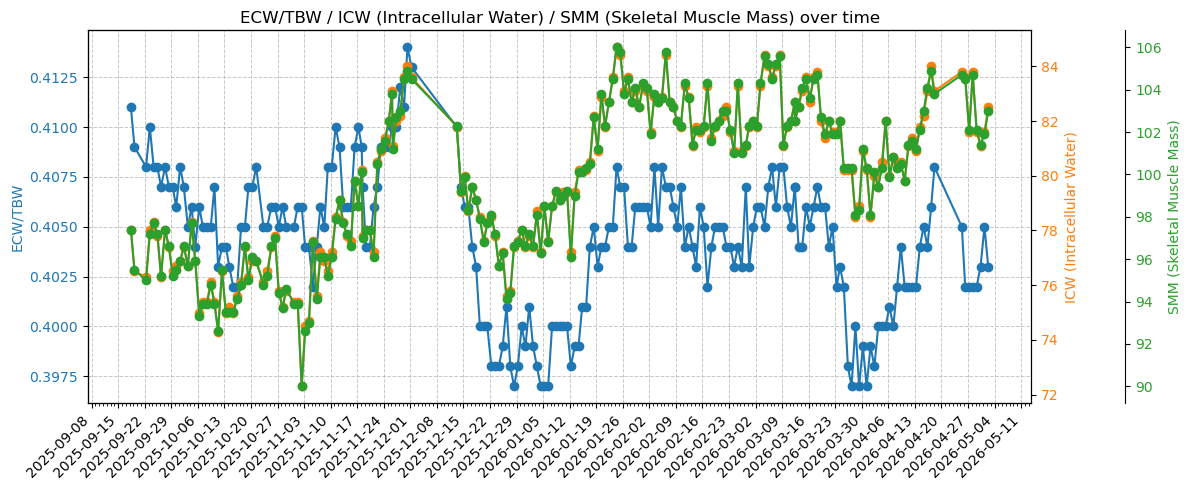

In [28]:
# Plots by subject
plt_lst = ["ECW/TBW","ICW (Intracellular Water)","SMM (Skeletal Muscle Mass)"]
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst)

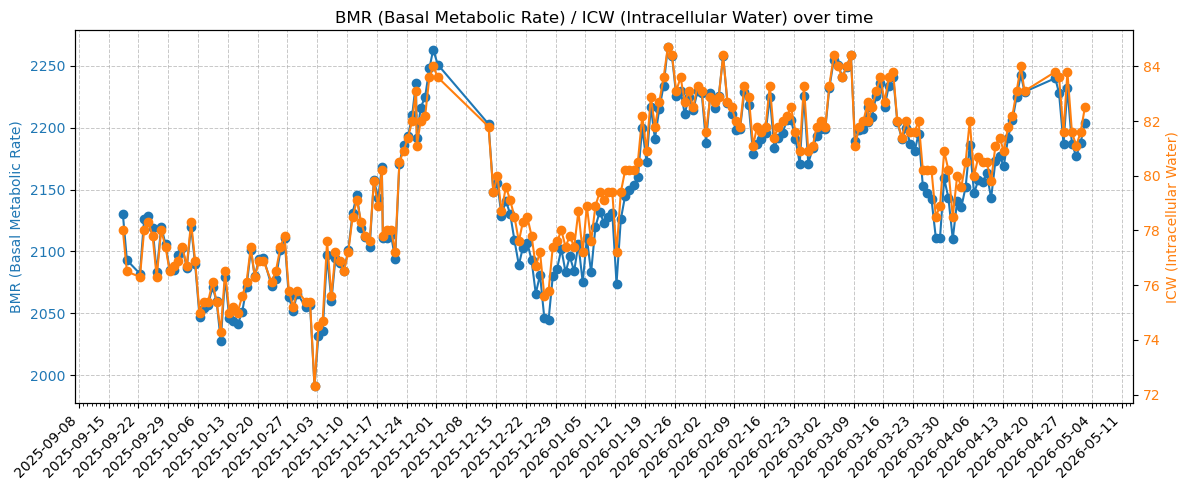

In [29]:
# Plots by subject
plt_lst = ['BMR (Basal Metabolic Rate)',"ICW (Intracellular Water)"]
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst )

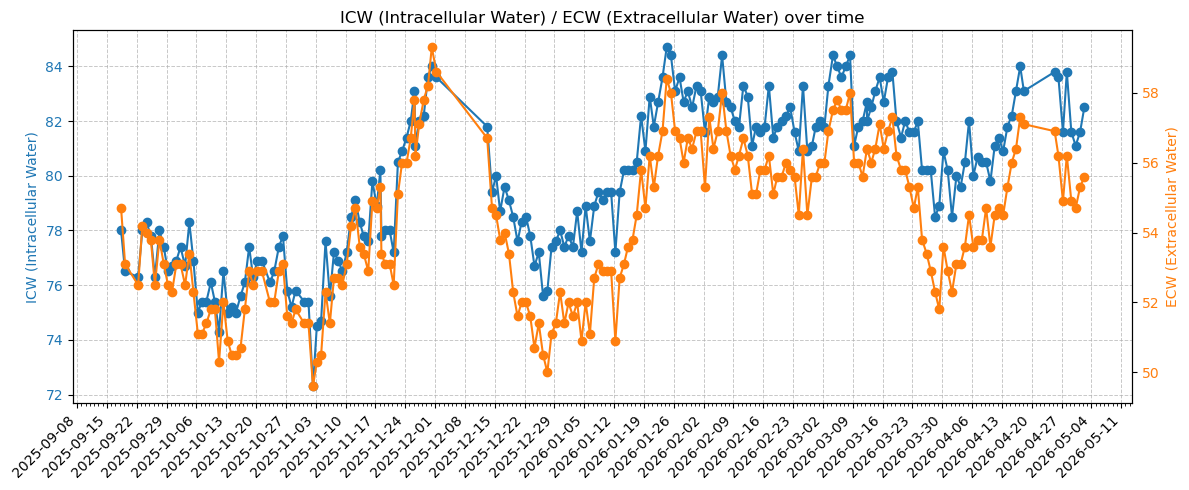

In [30]:
# Plots by subject
plt_lst = ["ICW (Intracellular Water)","ECW (Extracellular Water)"]
plot_multi_dual(df_mf_ib7797_nn_s_mrn, *plt_lst)

In [31]:
list(df_ib["ECW/TBW"] )

[0.415,
 0.41,
 0.407,
 0.414,
 0.406,
 0.413,
 0.406,
 0.411,
 0.404,
 0.407,
 0.403,
 0.409,
 0.4,
 0.406,
 0.4,
 0.409,
 0.4,
 0.405,
 0.398,
 0.403,
 0.398,
 0.405,
 0.398,
 0.406,
 0.399,
 0.408,
 0.401,
 0.404,
 0.398,
 0.403,
 0.397,
 0.402,
 0.398,
 0.406,
 0.4,
 0.404,
 0.399,
 0.401,
 0.406,
 0.399,
 0.403,
 0.398,
 0.405,
 0.397,
 0.404,
 0.397,
 0.404,
 0.397,
 0.405,
 0.4,
 0.408,
 0.4,
 0.405,
 0.4,
 0.405,
 0.4,
 0.406,
 0.4,
 0.406,
 0.398,
 0.404,
 0.399,
 0.402,
 0.399,
 0.406,
 0.401,
 0.409,
 0.401,
 0.41,
 0.404,
 0.411,
 0.405,
 0.41,
 0.403,
 0.411,
 0.404,
 0.413,
 0.404,
 0.412,
 0.405,
 0.411,
 0.405,
 0.415,
 0.408,
 0.415,
 0.407,
 0.412,
 0.415,
 0.407,
 0.412,
 0.404,
 0.411,
 0.404,
 0.415,
 0.406,
 0.413,
 0.406,
 0.415,
 0.406,
 0.413,
 0.406,
 0.414,
 0.405,
 0.415,
 0.408,
 0.413,
 0.405,
 0.413,
 0.408,
 0.414,
 0.407,
 0.417,
 0.407,
 0.415,
 0.406,
 0.411,
 0.405,
 0.414,
 0.407,
 0.411,
 0.404,
 0.411,
 0.405,
 0.412,
 0.404,
 0.41,
 0.403,
 0.41,

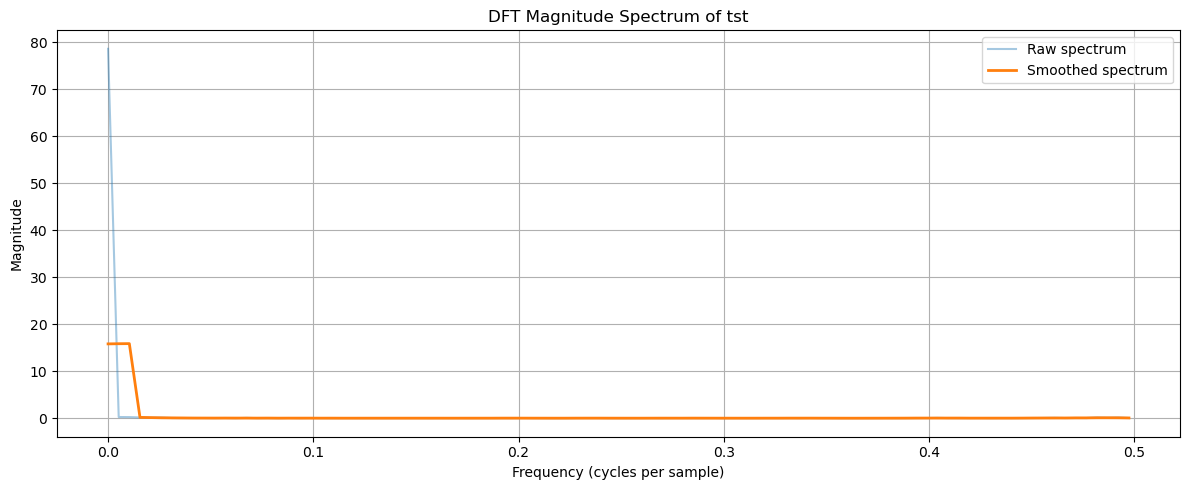

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Your data
tst = np.array([
0.414,0.409,0.408,0.41,0.412,0.408,0.408,0.407,0.408,0.407,0.41,0.407,0.406,
0.408,0.412,0.407,0.409,0.405,0.411,0.406,0.404,0.409,0.406,0.405,0.407,0.405,
0.408,0.405,0.41,0.407,0.408,0.408,0.403,0.407,0.404,0.409,0.404,0.405,0.403,
0.407,0.402,0.407,0.402,0.408,0.405,0.409,0.405,0.407,0.412,0.407,0.413,0.408,
0.411,0.411,0.405,0.41,0.405,0.41,0.406,0.411,0.406,0.409,0.405,0.41,0.406,
0.409,0.405,0.406,0.403,0.409,0.405,0.409,0.406,0.408,0.406,0.41,0.404,0.41,
0.404,0.408,0.402,0.408,0.404,0.409,0.406,0.411,0.405,0.411,0.408,0.412,0.413,
0.408,0.415,0.41,0.414,0.409,0.413,0.406,0.41,0.406,0.411,0.406,0.413,0.409,
0.414,0.41,0.412,0.409,0.407,0.41,0.408,0.404,0.409,0.404,0.41,0.406,0.41,
0.407,0.413,0.409,0.411,0.409,0.412,0.409,0.415,0.41,0.41,0.416,0.41,0.416,
0.412,0.413,0.411,0.414,0.414,0.417,0.413,0.41,0.409,0.415,0.41,0.407,0.414,
0.406,0.413,0.406,0.411,0.404,0.407,0.403,0.409,0.4,0.406,0.4,0.409,0.4,0.405,
0.398,0.403,0.398,0.405,0.398,0.406,0.399,0.408,0.401,0.404,0.398,0.403,0.397,
0.402,0.398,0.406,0.4,0.404,0.399,0.401,0.406,0.399,0.403,0.398,0.405,0.397,
0.404,0.397,0.404,0.397,0.405,0.4,0.408,0.4,0.405,0.4
])

N = len(tst)

# FFT
Y = np.fft.rfft(tst)
freqs = np.fft.rfftfreq(N, d=1)  # d=1 means "1 sample per unit time"

# Magnitude spectrum
mag = np.abs(Y)

# Optional smoothing to highlight major frequency ranges
window = 5
smooth_mag = np.convolve(mag, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,5))
plt.plot(freqs, mag, alpha=0.4, label="Raw spectrum")
plt.plot(freqs, smooth_mag, linewidth=2, label="Smoothed spectrum")
plt.title("DFT Magnitude Spectrum of tst")
plt.xlabel("Frequency (cycles per sample)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
import numpy as np

# Your data
tst = np.array([
0.414, 0.409, 0.408, 0.41, 0.412, 0.408, 0.408, 0.407, 0.408, 0.407,
0.41, 0.407, 0.406, 0.408, 0.412, 0.407, 0.409, 0.405, 0.411, 0.406,
0.404, 0.409, 0.406, 0.405, 0.407, 0.405, 0.408, 0.405, 0.41, 0.407,
0.408, 0.408, 0.403, 0.407, 0.404, 0.409, 0.404, 0.405, 0.403, 0.407,
0.402, 0.407, 0.402, 0.408, 0.405, 0.409, 0.405, 0.407, 0.412, 0.407,
0.413, 0.408, 0.411, 0.411, 0.405, 0.41, 0.405, 0.41, 0.406, 0.411,
0.406, 0.409, 0.405, 0.41, 0.406, 0.409, 0.405, 0.406, 0.403, 0.409,
0.405, 0.409, 0.406, 0.408, 0.406, 0.41, 0.404, 0.41, 0.404, 0.408,
0.402, 0.408, 0.404, 0.409, 0.406, 0.411, 0.405, 0.411, 0.408, 0.412,
0.413, 0.408, 0.415, 0.41, 0.414, 0.409, 0.413, 0.406, 0.41, 0.406,
0.411, 0.406, 0.413, 0.409, 0.414, 0.41, 0.412, 0.409, 0.407, 0.41,
0.408, 0.404, 0.409, 0.404, 0.41, 0.406, 0.41, 0.407, 0.413, 0.409,
0.411, 0.409, 0.412, 0.409, 0.415, 0.41, 0.41, 0.416, 0.41, 0.416,
0.412, 0.413, 0.411, 0.414, 0.414, 0.417, 0.413, 0.41, 0.409, 0.415,
0.41, 0.407, 0.414, 0.406, 0.413, 0.406, 0.411, 0.404, 0.407, 0.403,
0.409, 0.4, 0.406, 0.4, 0.409, 0.4, 0.405, 0.398, 0.403, 0.398, 0.405,
0.398, 0.406, 0.399, 0.408, 0.401, 0.404, 0.398, 0.403, 0.397, 0.402,
0.398, 0.406, 0.4, 0.404, 0.399, 0.401, 0.406, 0.399, 0.403, 0.398,
0.405, 0.397, 0.404, 0.397, 0.404, 0.397, 0.405, 0.4, 0.408, 0.4,
0.405, 0.4
])

N = len(tst)
Y = np.fft.rfft(tst)
freqs = np.fft.rfftfreq(N, d=1)  # 1 sample per unit time

mag = np.abs(Y)

# Ignore the DC component (index 0)
dominant_idx = np.argmax(mag[1:]) + 1
dominant_freq = freqs[dominant_idx]

# Convert to period (in samples)
if dominant_freq != 0:
    dominant_period = 1 / dominant_freq
else:
    dominant_period = np.inf

dominant_freq, dominant_period


(np.float64(0.0051813471502590676), np.float64(193.0))

In [34]:
def wiener_smooth(y, smooth_window=15):
    N = len(y)
    Y = np.fft.rfft(y)
    P = np.abs(Y)**2

    # Smooth the total spectrum to estimate Sxx + Snn
    kernel = np.ones(smooth_window) / smooth_window
    S_total = np.convolve(P, kernel, mode='same')

    # Estimate noise floor from highest 20% of frequencies
    hf = int(0.8 * len(P))
    noise_floor = np.median(P[hf:])
    Snn = noise_floor * np.ones_like(P)

    # Estimate signal spectrum
    Sxx = np.maximum(S_total - Snn, 0)

    # Wiener filter
    H = Sxx / (Sxx + Snn)
    Xhat = H * Y

    return np.fft.irfft(Xhat, n=N)

# wiener_output = wiener_smooth(tst)


In [35]:
wiener_output = wiener_smooth(tst)

In [36]:
def spectral_smooth(y, window=7):
    N = len(y)
    Y = np.fft.rfft(y)
    mag = np.abs(Y)
    phase = np.angle(Y)

    kernel = np.ones(window) / window
    mag_smooth = np.convolve(mag, kernel, mode='same')

    Y_smooth = mag_smooth * np.exp(1j * phase)
    return np.fft.irfft(Y_smooth, n=N)

spec_output = spectral_smooth(tst)


In [37]:
spec_output = spectral_smooth(tst)

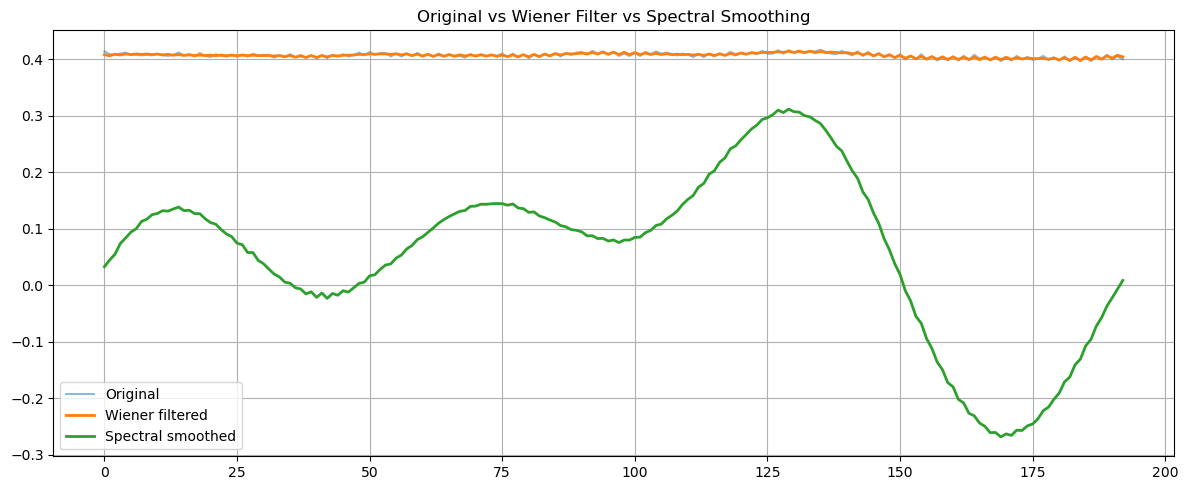

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tst, label="Original", alpha=0.5)
plt.plot(wiener_output, label="Wiener filtered", linewidth=2)
plt.plot(spec_output, label="Spectral smoothed", linewidth=2)
plt.title("Original vs Wiener Filter vs Spectral Smoothing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
dominant_period_samples = dominant_period  # from FFT
T_sample = 1.0  # e.g., 1 day per sample

dominant_period_real = dominant_period_samples * T_sample
print("Dominant period in real time:", dominant_period_real)


Dominant period in real time: 193.0


In [40]:
import numpy as np

tst = np.array([
    0.414,0.409,0.408,0.41,0.412,0.408,0.408,0.407,0.408,0.407,0.41,0.407,0.406,
    0.408,0.412,0.407,0.409,0.405,0.411,0.406,0.404,0.409,0.406,0.405,0.407,0.405,
    0.408,0.405,0.41,0.407,0.408,0.408,0.403,0.407,0.404,0.409,0.404,0.405,0.403,
    0.407,0.402,0.407,0.402,0.408,0.405,0.409,0.405,0.407,0.412,0.407,0.413,0.408,
    0.411,0.411,0.405,0.41,0.405,0.41,0.406,0.411,0.406,0.409,0.405,0.41,0.406,
    0.409,0.405,0.406,0.403,0.409,0.405,0.409,0.406,0.408,0.406,0.41,0.404,0.41,
    0.404,0.408,0.402,0.408,0.404,0.409,0.406,0.411,0.405,0.411,0.408,0.412,0.413,
    0.408,0.415,0.41,0.414,0.409,0.413,0.406,0.41,0.406,0.411,0.406,0.413,0.409,
    0.414,0.41,0.412,0.409,0.407,0.41,0.408,0.404,0.409,0.404,0.41,0.406,0.41,
    0.407,0.413,0.409,0.411,0.409,0.412,0.409,0.415,0.41,0.41,0.416,0.41,0.416,
    0.412,0.413,0.411,0.414,0.414,0.417,0.413,0.41,0.409,0.415,0.41,0.407,0.414,
    0.406,0.413,0.406,0.411,0.404,0.407,0.403,0.409,0.4,0.406,0.4,0.409,0.4,0.405,
    0.398,0.403,0.398,0.405,0.398,0.406,0.399,0.408,0.401,0.404,0.398,0.403,0.397,
    0.402,0.398,0.406,0.4,0.404,0.399,0.401,0.406,0.399,0.403,0.398,0.405,0.397,
    0.404,0.397,0.404,0.397,0.405,0.4,0.408,0.4,0.405,0.4
])

N = len(tst)
Y = np.fft.rfft(tst)
freqs = np.fft.rfftfreq(N, d=1)  # 1 sample per day

mag = np.abs(Y)

# Ignore DC (index 0)
dominant_idx = np.argmax(mag[1:]) + 1
dominant_freq = freqs[dominant_idx]
dominant_period_samples = 1 / dominant_freq if dominant_freq != 0 else np.inf

dominant_freq, dominant_period_samples


(np.float64(0.0051813471502590676), np.float64(193.0))

In [41]:
dominant_period_days = dominant_period_samples
dominant_period_weeks = dominant_period_days / 7
dominant_period_months = dominant_period_days / 30.44  # average month length

dominant_period_days, dominant_period_weeks, dominant_period_months


(np.float64(193.0),
 np.float64(27.571428571428573),
 np.float64(6.340341655716163))